In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# # import  settings
import plot_settings
plot_settings.apply()

In [2]:
import pybamm


model = pybamm.lithium_ion.SPM()

geometry = model.default_geometry



param = model.default_parameter_values

def my_current(t):
    return 1

In [3]:
#pybamm.sin(20 *np.pi* t / (3600)) + 1  # Example: sinusoidal current

param["Current function [A]"] = my_current


param.process_model(model)
param.process_geometry(geometry)

mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)

disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model)

In [4]:
# solve model
t_eval = [0,3*3600]
solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
solution = solver.solve(model, t_eval)

In [5]:
# # variables
# for k, v in zip(model.variables.keys(), model.variables.values()):
#     print(f"{k}\t\t{v}")

# model.print_parameter_info()
# print(param)

for var, eq in model.rhs.items():
    print(var, eq)

Discharge capacity [A.h] Column vector of length 1
Throughput capacity [A.h] Column vector of length 1
X-averaged negative particle concentration [mol.m-3] Column vector of length 20 + Sparse Matrix (20, 20) @ y[2:22]
X-averaged positive particle concentration [mol.m-3] Column vector of length 20 + Sparse Matrix (20, 20) @ y[22:42]


In [6]:
# plot = pybamm.QuickPlot(solution,
#                     output_variables=[
#                         "Negative particle concentration [mol.m-3]",
#                         "Positive particle concentration",
#                         "Negative electrode potential [V]",
#                         "Positive electrode potential [V]",
#                         "Electrolyte concentration [mol.m-3]",
#                         "Voltage [V]",
#                         "Current [A]",
#                     ])
# plot.dynamic_plot()

In [7]:
# n = 0
# f, ax = plt.subplots(int(138/2),2,figsize=(6,int(138*3)))
# for i,vals in enumerate(model.variables.keys()):
    
#     if solution[vals].entries.ndim == 1:
#         if solution[vals].entries[0] != solution[vals].entries[-1]:
            
#             if n % 2 == 1:
#                 j = 1
#             else:
#                 j = 0
            
#             ax[int(n/2),j].plot(solution["Time [s]"].entries, solution[vals].entries, label=vals)
#             ax[int(n/2),j].legend(fontsize=6)
#             n += 1
# plt.savefig('prg_figs/all_t_vars.pdf', bbox_inches='tight')
# plt.show()
#     #print(f'{solution[vals].entries.shape} \t {vals}')
# print(f'Total number of variables: {n}')

In [8]:
# n = 0

# t0 = 0; x0= 0
# f, ax = plt.subplots(int(20/2),2,figsize=(6,int(20*3)))
# for t0 in [0,-1]:
#     n = 0   
#     for i,vals in enumerate(model.variables.keys()):
        
#         if solution[vals].entries.shape[0] ==  solution['r_n [m]'].entries.shape[0]:
#             print(vals)
#             #if solution[vals].entries[0] != solution[vals].entries[-1]:

#             if n % 2 == 1:
#                     j = 1
#             else:
#                     j = 0
#             if solution[vals].entries.ndim == 2:
#                 ax[int(n/2),j].plot(solution["r_n [m]"].entries[:,x0,t0], solution[vals].entries[:,t0], label=vals)
#                 ax[int(n/2),j].legend(fontsize=6)
#             elif solution[vals].entries.ndim == 3:
#                 ax[int(n/2),j].plot(solution["r_n [m]"].entries[:,x0,t0], solution[vals].entries[:,x0,t0], label=vals)
#                 ax[int(n/2),j].legend(fontsize=6)
#             n += 1

# plt.savefig('prg_figs/all_r_vars.pdf', bbox_inches='tight')
# #plt.show()
#     #print(f'{solution[vals].entries.shape} \t {vals}')
print(f'Total number of variables: {n}')

NameError: name 'n' is not defined

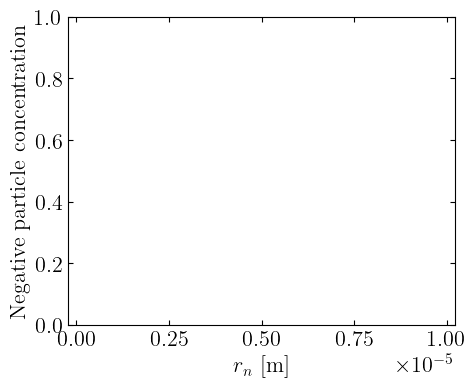

In [ ]:
c_s_n = solution["Negative particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries[:, 0,1]

t = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

def plot_concentrations(t):
    fig, ax1 = plt.subplots(1, 1, figsize=(5, 4))
    
    # Evaluate concentration at specific time and x position (returns values at all r points)
    c_vals = c_s_n(r=r_n, t=t, x=x[0])
    
    # Get the r coordinate values - use entries to get the proper array shape
    r_vals = c_s_n.entries[:, 0, 0]  # Get r values from the data structure
    
    (_plot_c_n,) = ax1.plot(r_n, c_vals)
    ax1.set_ylabel("Negative particle concentration")
    ax1.set_xlabel(r"$r_n$ [m]")
    ax1.set_ylim(0, 1)

plot_concentrations(t=1800)  # plot at 1800 s

In [ ]:
import matplotlib as mpl

# Solution variables
c_s_n = solution["Positive particle concentration [mol.m-3]"]
r_n = solution["r_n [m]"].entries         # shape (nr, nx, nt)
x_n = solution["x_n [m]"].entries         # shape (nx, nt)
t_vals = solution["Time [s]"].entries     # shape (nt,)

# Choose a time index
t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))

# Extract r grid and x grid at that time
# r_n is (nr, nx, nt) so take r_n[..., ti]
r2d = r_n[..., ti]    # shape (nr, nx)
x2d = x_n[..., ti]    # shape (nx,)

# Concentration is (nr, nx, nt) as well
c2d = c_s_n.entries[..., ti]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
X, R = np.meshgrid(x2d, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(X, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$x_n$ [m]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at $t$")

AttributeError: 'NoneType' object has no attribute 'nodes_lr'

In [ ]:
c_s_n = solution["Positive particle concentration [mol.m-3]"].entries
r_n = solution["r_n [m]"].entries 
t_vals = solution["Time [s]"].entries  
print(t_vals.shape)
print(r_n.shape)
print(c_s_n.shape)


t0 = 3500
# find nearest index in the time array
ti = np.argmin(np.abs(t_vals - t0))



xi =0
r2d = r_n[:,xi,:]    # shape (nr, nx)
c2d = c_s_n[:,xi,:]  # shape (nr, nx)

# Now plot
fig, ax = plt.subplots(figsize=(6, 4))
T, R = np.meshgrid(t_vals, r2d[:, 0])  # r varies along rows, x along columns

cs = ax.contourf(T, R, c2d, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax, label="$c_{sn}$ [mol·m3]")

ax.set_xlabel("$t$ [s]")
ax.set_ylabel("$r_n$ [m]")
ax.set_title(f"Negative particle concentration at t")



AttributeError: 'NoneType' object has no attribute 'nodes_lr'

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

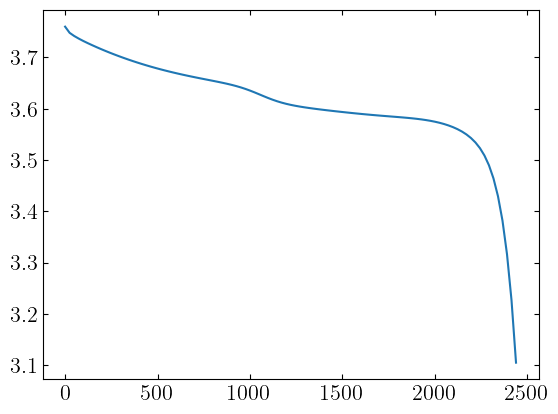

In [ ]:
npc = solution.observe(model.variables['Voltage [V]'])

t_ = np.linspace(0,solution['Time [s]'].entries[-1],101)
plt.plot(t_,npc(t_))

print(npc(t_)[0,0,:].shape)

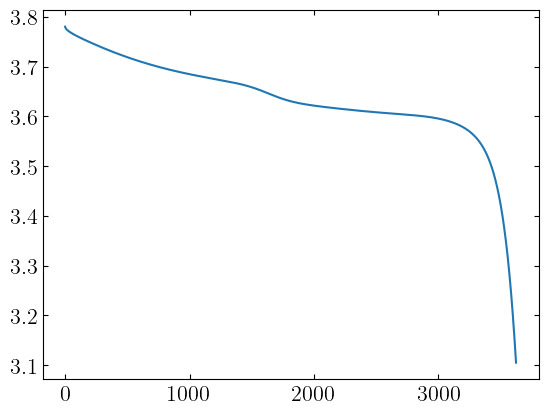

In [ ]:
V = solution.observe(model.variables['Voltage [V]'])

t_ = np.linspace(0,solution['Time [s]'].entries[-1],int(solution['Time [s]'].entries[-1]))
plt.plot(t_,V(t_))



Text(0, 0.5, 'Normalized surface concentration')

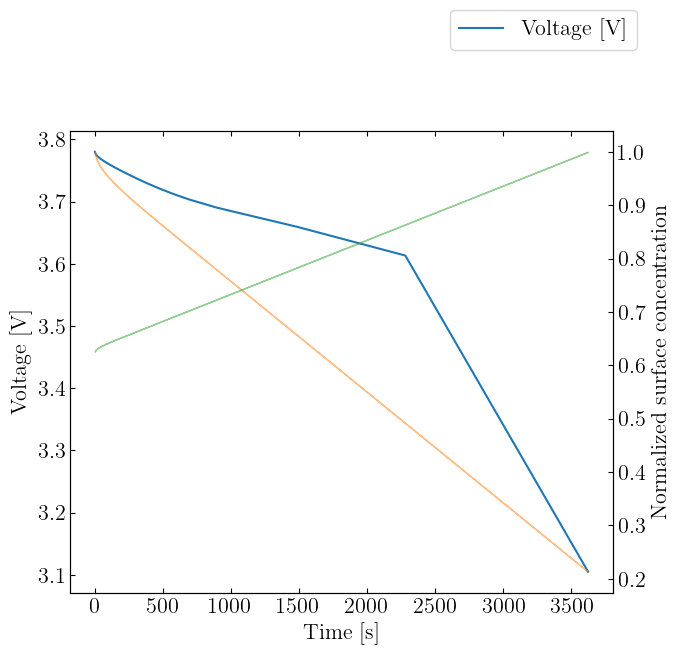

In [ ]:
plot2 = 'Negative particle surface concentration [mol.m-3]'

T = solution["Time [s]"].entries
cn = solution[plot2].entries
cp = solution['Positive particle surface concentration [mol.m-3]'].entries
V = solution["Terminal voltage [V]"].entries

f,ax = plt.subplots(1,1,figsize=(7,6))
ax1 =ax.twinx()
ax.plot(T,V,color = 'tab:blue',label = 'Voltage [V]')

ax1.fill_between(T,cn[0]/np.max(cn[0]),cn[-1]/np.max(cn[-1]),color = 'tab:orange',alpha=0.5)
ax1.fill_between(T,cp[0]/np.max(cp[0]),cp[-1]/np.max(cp[-1]),color = 'tab:green',alpha=0.5)
#ax1.plot(T,solution[''].entries,color='tab:orange',label='Neg. particle surf. conc.'   )
    
    #ax1.plot(T,cp[r]/np.max(cp[r]) - cn[r]/np.max(cn[r]),color = 'tab:red')
f.legend(bbox_to_anchor=(0.95,1.1))    
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax1.set_ylabel('Normalized surface concentration')